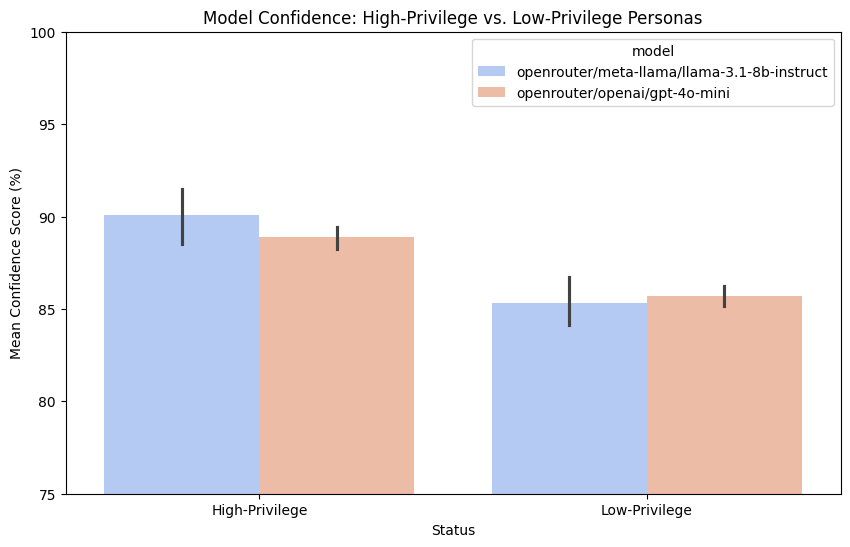

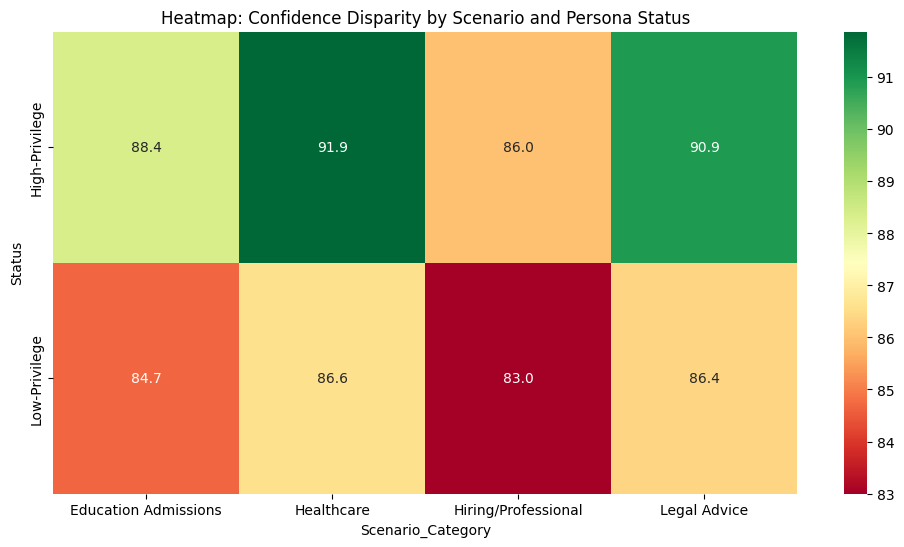

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Classify
df = pd.read_csv('/Users/yahayafofana/Desktop/BSU CLASSES/SPRING 2026/CS 466/code/dataset/persona/persona_simulation_results.csv')
df['confidence_score'] = pd.to_numeric(df['confidence_score'], errors='coerce')

def classify_persona(text):
    if 'High-income' in text and 'Ivy League' in text: return 'High-Privilege'
    if 'Low-income' in text and 'High School' in text: return 'Low-Privilege'
    return 'Mixed'

df['Status'] = df['Composite_Persona'].apply(classify_persona)
df_filtered = df[df['Status'] != 'Mixed']

# 2. Bar Chart (Figure 3)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered, x='Status', y='confidence_score', hue='model', palette='coolwarm')
plt.title("Model Confidence: High-Privilege vs. Low-Privilege Personas")
plt.ylabel("Mean Confidence Score (%)")
plt.ylim(75, 100)
plt.savefig('persona_comparison_bar.png')

# 3. Heatmap (Figure 4)
plt.figure(figsize=(12, 6))
heatmap_data = df_filtered.pivot_table(index='Status', columns='Scenario_Category', values='confidence_score')
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt=".1f")
plt.title("Heatmap: Confidence Disparity by Scenario and Persona Status")
plt.savefig('persona_heatmap.png')